# Notebook 01 — Validação do modelo e gráficos

Notebook para gerar curva Top-K, churn por safra e tabelas de validação.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa


try:
    pa.unregister_extension_type("pandas.period")
except Exception:
    pass


PROJECT_ROOT = Path.cwd().parent

SCORES_TEST = PROJECT_ROOT / "data" / "processed" / "scores_test.parquet"
MODEL_TABLE = PROJECT_ROOT / "data" / "processed" / "model_table"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SCORES_TEST exists:", SCORES_TEST.exists(), SCORES_TEST)
print("MODEL_TABLE exists:", MODEL_TABLE.exists(), MODEL_TABLE)

scores = pd.read_parquet(SCORES_TEST, engine="pyarrow")
model = pd.read_parquet(MODEL_TABLE, engine="pyarrow")

scores["safra"] = pd.to_numeric(scores["safra"], errors="coerce").astype("int32")
scores["churn_3m"] = pd.to_numeric(scores["churn_3m"], errors="coerce").astype("int8")

print("scores shape:", scores.shape)
print("model shape:", model.shape)
scores.head()

PROJECT_ROOT: /home/eragom/Documentos/case_datamaster/case_churn
SCORES_TEST exists: True /home/eragom/Documentos/case_datamaster/case_churn/data/processed/scores_test.parquet
MODEL_TABLE exists: True /home/eragom/Documentos/case_datamaster/case_churn/data/processed/model_table
scores shape: (2987795, 4)
model shape: (17026533, 32)


,msno,safra,churn_3m,p_churn
0,+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=,201606,0,0.147165
1,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,201606,0,0.014042
2,++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=,201606,0,0.016307
3,++0+IdHga8fCSioOVpU8K7y4Asw8AveIApVH2r9q9yY=,201606,1,0.138653
4,++0/NopttBsaAn6qHZA2AWWrDg7Me7UOMs1vsyo4tSI=,201606,0,0.011153


In [2]:
base_churn = scores["churn_3m"].mean()
print("Base churn TEST:", round(base_churn, 6))

Base churn TEST: 0.047393


In [3]:
def recall_at_k(y_true, y_score, frac):
    k = max(1, int(len(y_true) * frac))
    idx = np.argsort(-y_score)[:k]
    return float(y_true.iloc[idx].sum() / y_true.sum()), k

def churnrate_at_k(y_true, y_score, frac):
    k = max(1, int(len(y_true) * frac))
    idx = np.argsort(-y_score)[:k]
    return float(y_true.iloc[idx].mean()), k

rows = []
for frac in [0.01, 0.03, 0.05, 0.10, 0.20]:
    rec, k = recall_at_k(scores["churn_3m"], scores["p_churn"], frac)
    cr, _ = churnrate_at_k(scores["churn_3m"], scores["p_churn"], frac)
    rows.append({"top_frac": frac, "k": k, "recall": rec, "churn_rate": cr})

curve = pd.DataFrame(rows)
curve["lift"] = curve["churn_rate"] / base_churn
curve

,top_frac,k,recall,churn_rate,lift
0,0.01,29877,0.002924,0.013857,0.292378
1,0.03,89633,0.013220,0.020885,0.440676
2,0.05,149389,0.087880,0.083299,1.757611
3,0.10,298779,0.334473,0.158519,3.344732
4,0.20,597559,0.740653,0.175511,3.703267


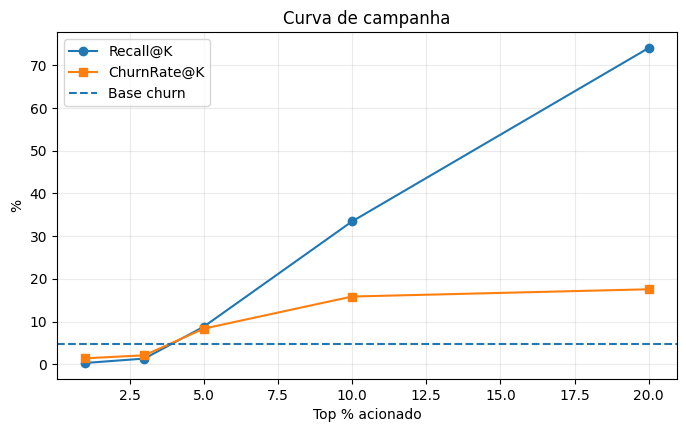

In [4]:
plt.figure(figsize=(8,4.5))
plt.plot(curve["top_frac"]*100, curve["recall"]*100, marker="o", label="Recall@K")
plt.plot(curve["top_frac"]*100, curve["churn_rate"]*100, marker="s", label="ChurnRate@K")
plt.axhline(base_churn*100, linestyle="--", label="Base churn")
plt.xlabel("Top % acionado")
plt.ylabel("%")
plt.title("Curva de campanha")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [5]:
df = pd.read_parquet(MODEL_TABLE)
df["safra"] = pd.to_numeric(df["safra"], errors="coerce").astype("int32")
df["churn_3m"] = pd.to_numeric(df["churn_3m"], errors="coerce").fillna(0).astype("int8")
df["is_ativo"] = pd.to_numeric(df["is_ativo"], errors="coerce").fillna(0).astype("int8")
df["label_trust"] = pd.to_numeric(df["label_trust"], errors="coerce").fillna(0).astype("int8")

trusted = df[(df["is_ativo"] == 1) & (df["label_trust"] == 1)].copy()
churn_by_month = trusted.groupby("safra", as_index=False)["churn_3m"].mean()
churn_by_month

,safra,churn_3m
0,201601,0.139944
1,201602,0.140160
2,201603,0.078067
3,201604,0.045341
4,201605,0.048684
5,201606,0.049240
6,201607,0.033494
7,201608,0.056631
8,201609,0.050325


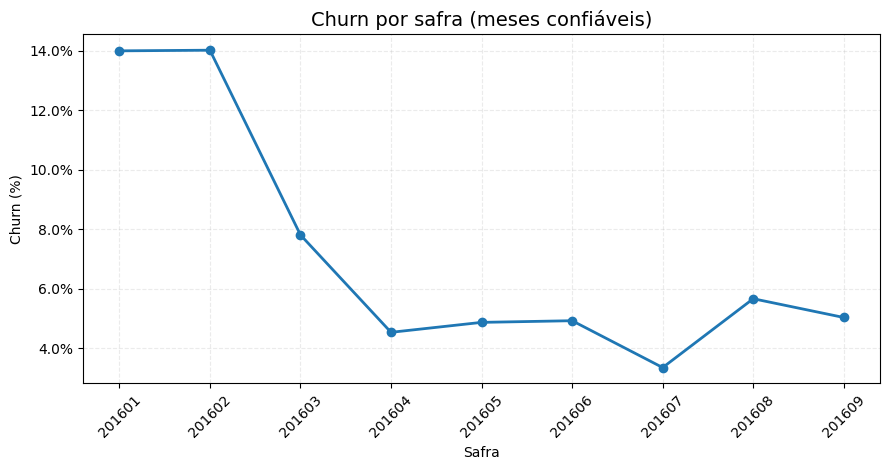

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# churn_by_month precisa ter as colunas: safra e churn_3m
# Exemplo:
# churn_by_month = trusted.groupby("safra", as_index=False)["churn_3m"].mean()

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.plot(
    churn_by_month["safra"].astype(str),
    churn_by_month["churn_3m"] * 100,
    marker="o",
    linewidth=2,
)

ax.set_title("Churn por safra (meses confiáveis)", fontsize=14)
ax.set_xlabel("Safra")
ax.set_ylabel("Churn (%)")

# grade mais suave
ax.grid(alpha=0.25, linestyle="--")

# força mostrar cada safra no eixo X
ax.set_xticks(range(len(churn_by_month)))
ax.set_xticklabels(churn_by_month["safra"].astype(str), rotation=45)

# mostra % no eixo Y
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()